In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/AAPL.csv")

In [4]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [8]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

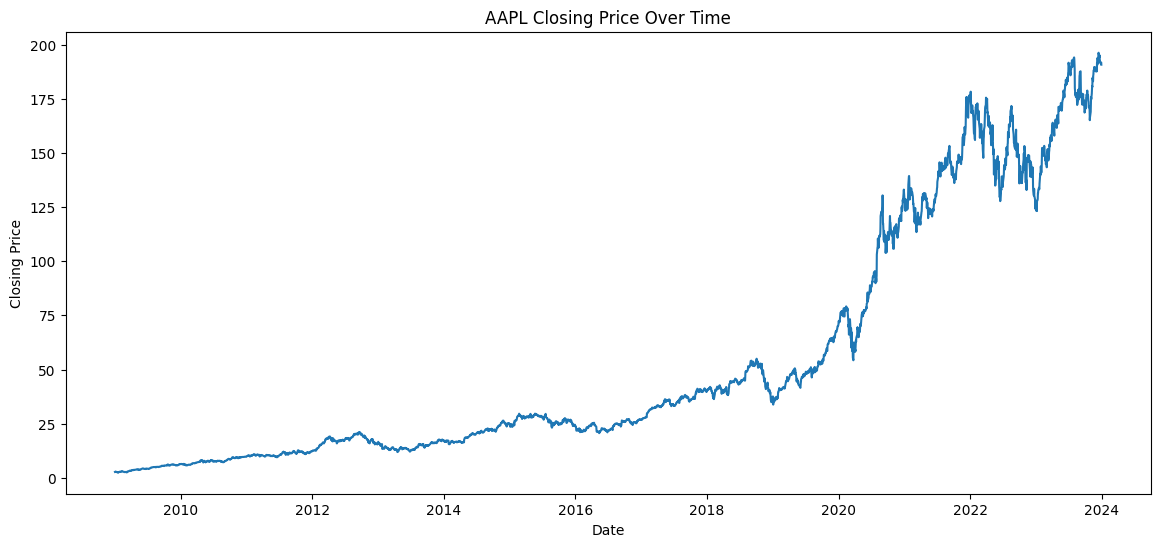

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

In [10]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

In [11]:
df[["Date", "Close", "SMA_20"]].head(25)

,Date,Close,SMA_20
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,NaN
2,2009-01-06,2.789767,NaN
3,2009-01-07,2.729484,NaN
4,2009-01-08,2.780169,NaN
5,2009-01-09,2.716589,NaN
6,2009-01-12,2.659007,NaN
7,2009-01-13,2.630514,NaN
8,2009-01-14,2.559135,NaN
9,2009-01-15,2.500652,NaN


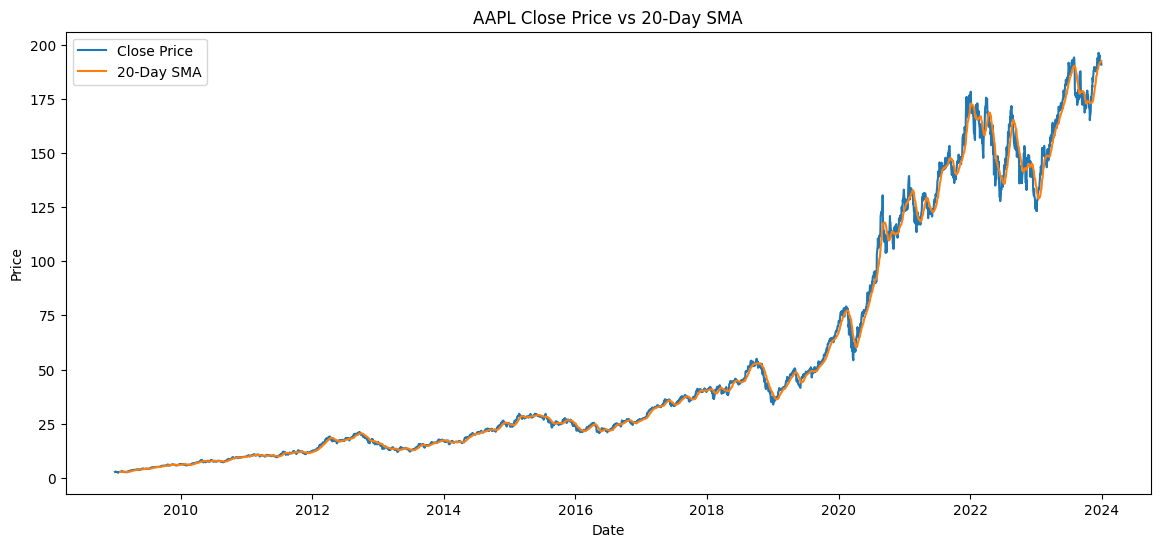

In [12]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="20-Day SMA")

plt.title("AAPL Close Price vs 20-Day SMA")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [13]:
df["SMA_50"] = df["Close"].rolling(window=50).mean()

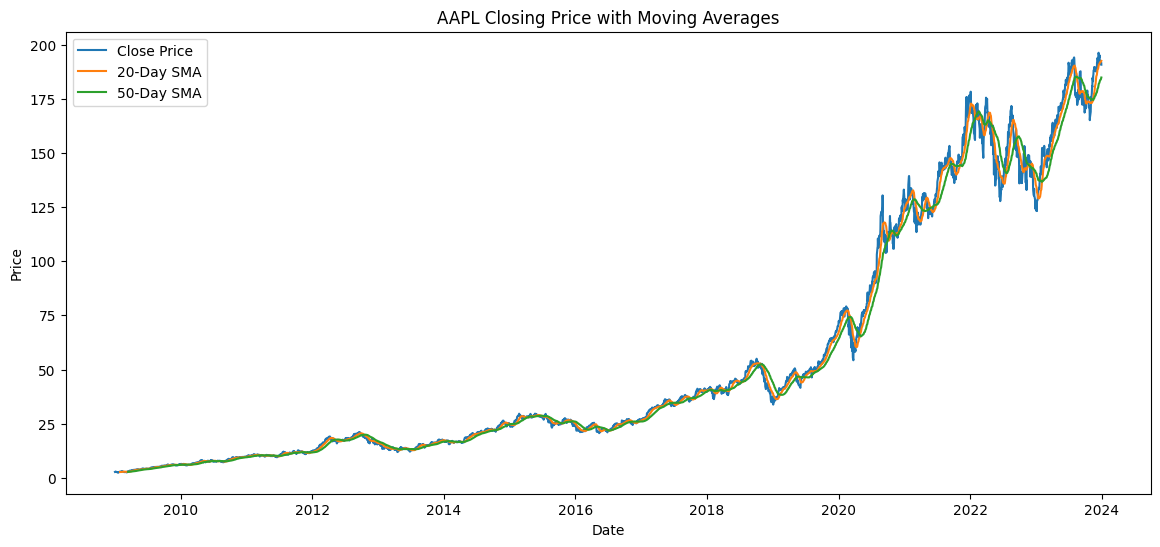

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="20-Day SMA")
plt.plot(df["Date"], df["SMA_50"], label="50-Day SMA")

plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

visualizing:

short-term trend → SMA_20
medium-term trend → SMA_50

In [15]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()

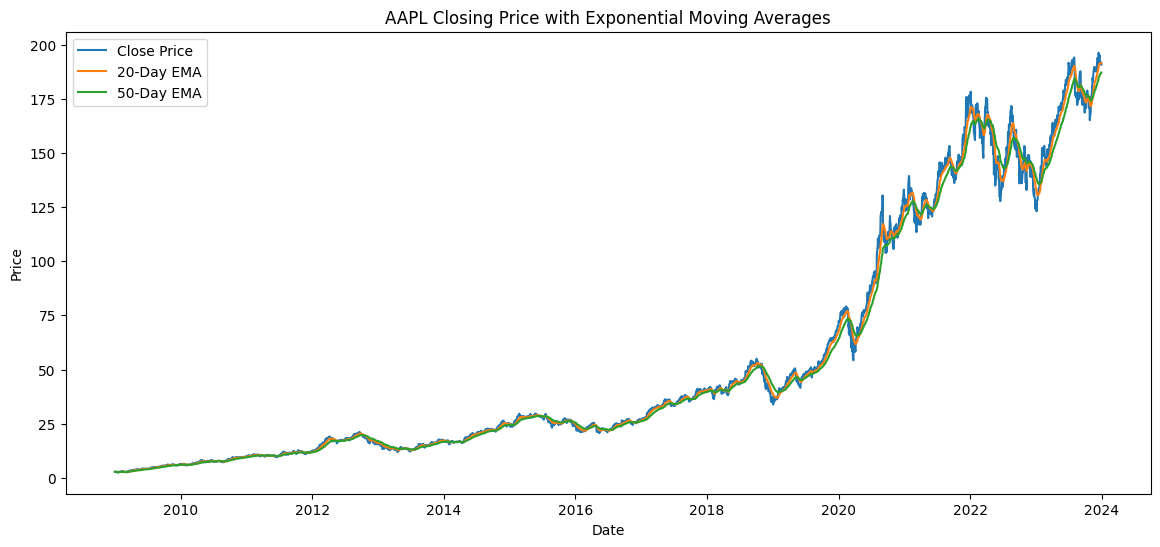

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["EMA_20"], label="20-Day EMA")
plt.plot(df["Date"], df["EMA_50"], label="50-Day EMA")

plt.title("AAPL Closing Price with Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

## Interpretation

The EMA indicators provide a smoother representation of stock price movement while remaining sensitive to recent market changes.

When the short-term EMA crosses above the long-term EMA, it may indicate bullish momentum. Conversely, when the short-term EMA crosses below the long-term EMA, it may suggest bearish momentum.

In [17]:
delta = df["Close"].diff()

In [18]:
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

In [19]:
rs = gain / loss

In [20]:
df["RSI_14"] = 100 - (100 / (1 + rs))

RSI Visualization

This plot shows RSI over time along with key thresholds:
- 70 (Overbought)
- 30 (Oversold)

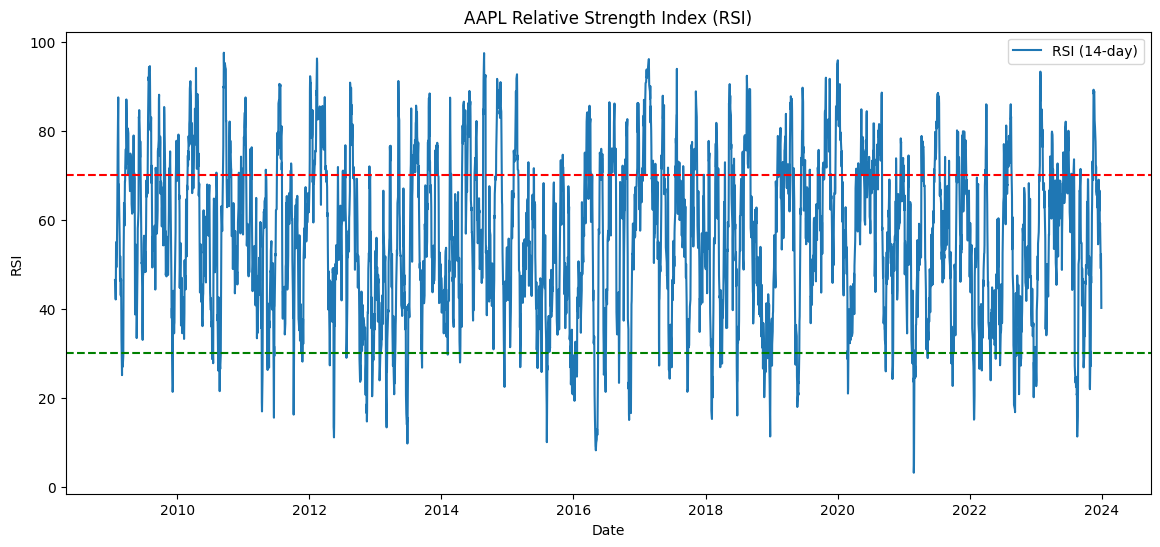

In [21]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["RSI_14"], label="RSI (14-day)")

plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")

plt.title("AAPL Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()

plt.show()

Moving Average Convergence Divergence (MACD)

In [22]:
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

In [23]:
df["MACD"] = ema_12 - ema_26

In [24]:
df["Signal_Line"] = df["MACD"].ewm(span=9, adjust=False).mean()

In [25]:
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

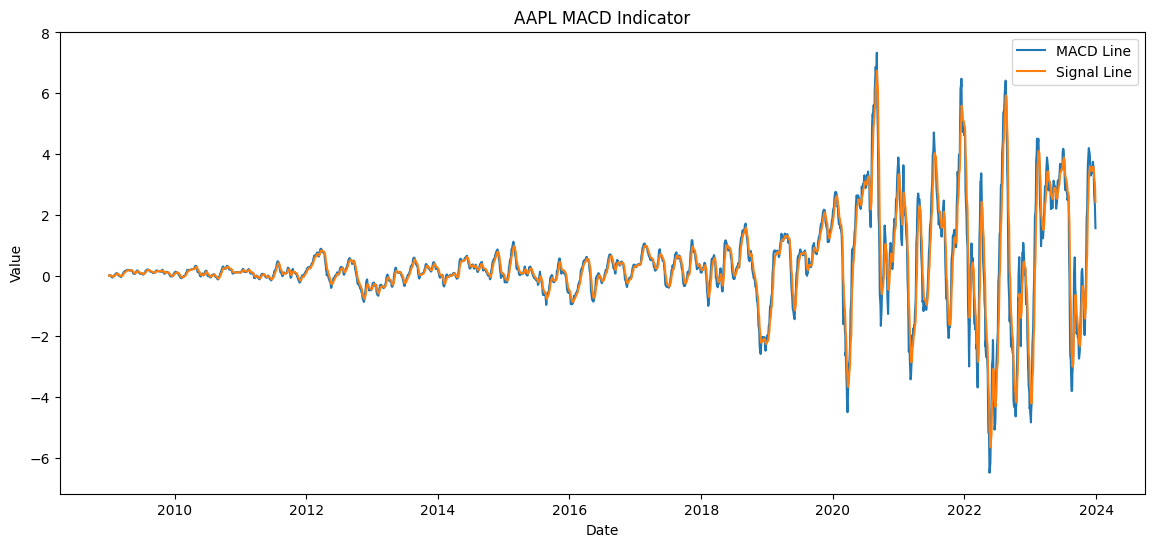

In [27]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["MACD"], label="MACD Line")
plt.plot(df["Date"], df["Signal_Line"], label="Signal Line")

plt.title("AAPL MACD Indicator")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()

plt.show()

This chart shows:
- MACD line (trend momentum)
- Signal line (smoothed trend)
- Histogram (momentum strength)

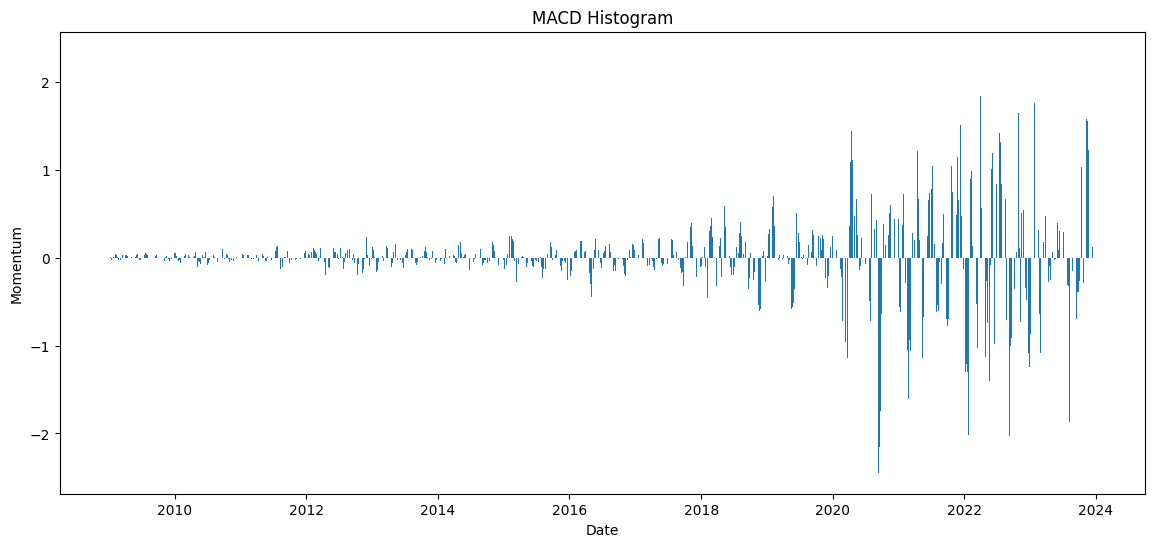

In [ ]:
plt.figure(figsize=(14,6))

plt.bar(df["Date"], df["MACD_Hist"])

plt.title("MACD Histogram")
plt.xlabel("Date")
plt.ylabel("Momentum")

plt.show()

In [35]:
import talib

In [36]:
df["RSI"] = talib.RSI(df["Close"], timeperiod=14)

In [38]:
df = df.dropna()

RSI measures momentum and helps identify overbought or oversold conditions in the stock price.